In [2]:
import importlib
import numpy as np
import seaborn as sns
sns.set_theme()
import matplotlib.pyplot as plt

# adjust path
path_to_hkpt = '../'
import sys
sys.path.append(path_to_hkpt)

import hk_parallel_transport as hkpt
hkpt = importlib.reload(hkpt)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})


/home/tsaidi/research/Sp26/HKPT/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Scaled mean_1: [0.], Scaled sigma_1: 0.04228364945489172
Scaled mean_2: [0.74747638], Scaled sigma_2: 0.04228364945489172
Scaled mean_3: [1.19596221], Scaled sigma_3: 0.04228364945489172
mu3 mean: 1.1977491280891008, mu3 var: 0.04345958436650065
mu3_at_mu2 mean: 1.1953561210225194, mu3_at_mu2 var: 0.028148838965097154


KeyboardInterrupt: 

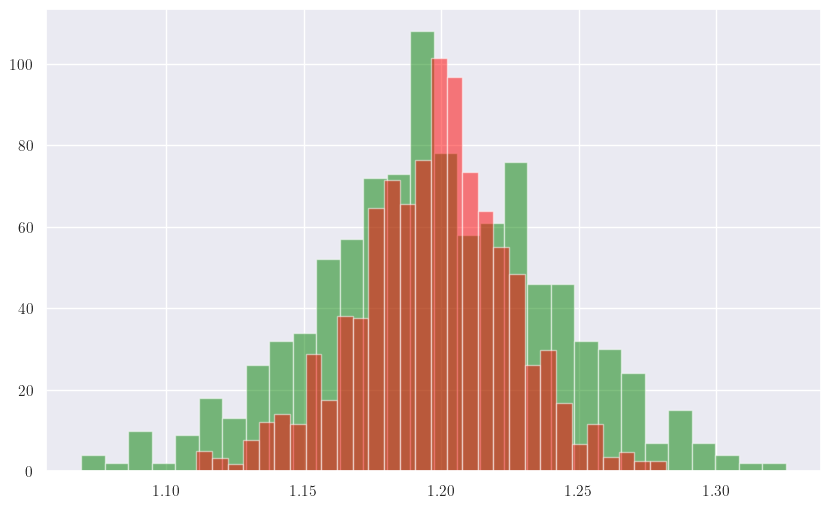

In [45]:
n_1 = 1000
n_2 = 1000
n_3 = 1000

mean_1 = np.array([0.0])
cov_1 = np.array([[2.0]])
mean_2 = np.array([25.0])
cov_2 = np.array([[2.0]])
mean_3 = np.array([40.0])
cov_3 = np.array([[2.0]])

data_1 = np.random.multivariate_normal(mean_1, cov_1, n_1)
data_2 = np.random.multivariate_normal(mean_2, cov_2, n_2)
data_3 = np.random.multivariate_normal(mean_3, cov_3, n_3)

# scale everything to < pi/4
max_val = max(np.max(data_1), np.max(data_2), np.max(data_3))
min_val = min(np.min(data_1), np.min(data_2), np.min(data_3))
scale_factor = ((np.pi / 2) - 1e-1) / (max_val - min_val)
data_1 *= scale_factor
data_2 *= scale_factor
data_3 *= scale_factor
# print(scaled means and covariances)
print(f"Scaled mean_1: {mean_1 * scale_factor}, Scaled sigma_1: {np.sqrt(cov_1[0, 0]) * scale_factor}")
print(f"Scaled mean_2: {mean_2 * scale_factor}, Scaled sigma_2: {np.sqrt(cov_2[0, 0]) * scale_factor}")
print(f"Scaled mean_3: {mean_3 * scale_factor}, Scaled sigma_3: {np.sqrt(cov_3[0, 0]) * scale_factor}")

mu1 = hkpt.EmpiricalMeasure(data_1, weights=np.ones(n_1))
mu2 = hkpt.EmpiricalMeasure(data_2, weights=np.ones(n_2))
mu3 = hkpt.EmpiricalMeasure(data_3, weights=np.ones(n_3))

tangent_23 = hkpt.hk_logarithmic_map(
    mu2,
    mu3, 
    allow_approximation=True, 
    approximation_mode='barycentric',
)

# diagnostic: plot mu3 and \hat mu3 = exp(log(mu2, mu3)) on the same plot
mu3_at_mu2 = hkpt.hk_exponential_map(mu2, tangent_23)
plt.figure(figsize=(10, 6))
plt.hist(data_3.flatten(), bins=30, weights=mu3.weights, label=r'$\mu_3$', color='green', alpha=0.5);
plt.hist(mu3_at_mu2.samples.flatten(), bins=30, weights=mu3_at_mu2.weights, label=r'$\hat{\mu}_3 = \exp_{\mu_2}(\log_{\mu2}(\mu_3))$', color='red', alpha=0.5);

# print mean and var of mu3 and mu3_at_mu2 locations (not weights)
print(f"mu3 mean: {np.mean(mu3.samples.flatten())}, mu3 var: {np.mean((mu3.samples.flatten() - np.mean(mu3.samples.flatten() ))**2 ) ** 0.5}")
print(f"mu3_at_mu2 mean: {np.mean(mu3_at_mu2.samples.flatten())}, mu3_at_mu2 var: {np.mean((mu3_at_mu2.samples.flatten() - np.mean(mu3_at_mu2.samples.flatten() ))**2 ) ** 0.5}")

# parallel transport tangent_23 from mu2 to mu1
tangent_23_at_mu1, pt_alignment_diag = hkpt.hk_parallel_transport(
    mu2,
    mu1,
    tangent_23,
    N = 4,
    return_alignment_diagnostics=True,
)

if pt_alignment_diag['alignment_succeeded']:
    print(f"Parallel transport alignment succeeded")
else:
    print(f"Parallel transport alignment failed with final alignment error {pt_alignment_diag['nearest_neighbor_distances'].max()}")

mu3_at_mu1 = hkpt.hk_exponential_map(mu1, tangent_23_at_mu1)

# plot all four measures on the same plot as unnormalized histograms with weights from the empirical measures
plt.figure(figsize=(10, 6))
plt.hist(data_1.flatten(), bins=15, weights=mu1.weights, label=r'$\mu_1$', color='blue', alpha=0.5);
plt.hist(data_2.flatten(), bins=15, weights=mu2.weights, label=r'$\mu_2$', color='orange', alpha=0.5);
plt.hist(data_3.flatten(), bins=15, weights=mu3.weights, label=r'$\mu_3$', color='green', alpha=0.5);
if mu3_at_mu1 is not None:
    plt.hist(mu3_at_mu1.samples.flatten(), bins=15, weights=mu3_at_mu1.weights, label=r'$\mathrm{PT}_{\mu_2 \rightarrow \mu_1}(\mathbf{log}_{\mu_2}(\mu_3))$', color='red', alpha=0.5);
# add legend underneath the plot
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.0),
    fancybox=True,
    shadow=True,
    ncol=4,
)
# no ticks
plt.xticks([]);
plt.yticks([]);
plt.ylim(0, plt.ylim()[1] * 1.1)
# add floating text at the mean of each distribution with total mass (sum of weights) in legend
x_mu1 = float(np.ravel(mean_1)[0]) * scale_factor
x_mu2 = float(np.ravel(mean_2)[0]) * scale_factor
x_mu3 = float(np.ravel(mean_3)[0]) * scale_factor
plt.text(x_mu1, plt.ylim()[1] * 0.9, f"Mass: {mu1.weights.sum():.2f}", color='blue', ha='center')
plt.text(x_mu2, plt.ylim()[1] * 0.9, f"Mass: {mu2.weights.sum():.2f}", color='orange', ha='center')
plt.text(x_mu3, plt.ylim()[1] * 0.9, f"Mass: {mu3.weights.sum():.2f}", color='green', ha='center')
if mu3_at_mu1 is not None:
    plt.text(np.mean(mu3_at_mu1.samples.flatten()), plt.ylim()[1] * 0.9, f"Mass: {mu3_at_mu1.weights.sum():.2f}", color='red', ha='center')
plt.savefig('../Figures/HK_parallel_transport_1d_mean_shift.pdf', dpi=800)


# print means and variances of all measures
print(f"mu1 mean: {np.mean(mu1.samples.flatten())}, mu1 var: {np.mean((mu1.samples.flatten() - np.mean(mu1.samples.flatten() ))**2 ) ** 0.5}")
print(f"mu2 mean: {np.mean(mu2.samples.flatten())}, mu2 var: {np.mean((mu2.samples.flatten() - np.mean(mu2.samples.flatten() ))**2 ) ** 0.5}")
print(f"mu3 mean: {np.mean(mu3.samples.flatten())}, mu3 var: {np.mean((mu3.samples.flatten() - np.mean(mu3.samples.flatten() ))**2 ) ** 0.5}")
if mu3_at_mu1 is not None:
    print(f"mu3_at_mu1 mean: {np.mean(mu3_at_mu1.samples.flatten())}, mu3_at_mu1 var: {np.mean((mu3_at_mu1.samples.flatten() - np.mean(mu3_at_mu1.samples.flatten() ))**2 ) ** 0.5}")

# print mass of all measures
print(f"mu1 mass: {mu1.weights.sum()}")
print(f"mu2 mass: {mu2.weights.sum()}")
print(f"mu3 mass: {mu3.weights.sum()}")
if mu3_at_mu1 is not None:
    print(f"mu3_at_mu1 mass: {mu3_at_mu1.weights.sum()}")

# print HK distance between mu1 and mu3, and between mu1 and mu3_at_mu1
hk_distance_mu2_mu3 = hkpt.hk_distance(mu2, mu3)
hk_distance_mu1_mu3_at_mu1 = hkpt.hk_distance(mu1, mu3_at_mu1)
print(f"HK distance between mu2 and mu3: {hk_distance_mu2_mu3}")
print(f"HK distance between mu1 and mu3_at_mu1: {hk_distance_mu1_mu3_at_mu1}")

In [ ]:
n_1 = 2000
n_2 = 2000
n_3 = 2000

mean_1 = np.array([0.0])
cov_1 = np.array([[2.0]])
mean_2 = np.array([30.0])
cov_2 = np.array([[2.0]])
mean_3 = np.array([40.0])
cov_3 = np.array([[8.0]])

data_1 = np.random.multivariate_normal(mean_1, cov_1, n_1)
data_2 = np.random.multivariate_normal(mean_2, cov_2, n_2)
data_3 = np.random.multivariate_normal(mean_3, cov_3, n_3)

# scale everything to < pi/4
max_val = max(np.max(data_1), np.max(data_2), np.max(data_3))
min_val = min(np.min(data_1), np.min(data_2), np.min(data_3))
scale_factor = ((np.pi / 2) - 1e-1) / (max_val - min_val)
data_1 *= scale_factor
data_2 *= scale_factor
data_3 *= scale_factor

mu1 = hkpt.EmpiricalMeasure(data_1, weights=np.ones(n_1))
mu2 = hkpt.EmpiricalMeasure(data_2, weights=np.ones(n_2))
mu3 = hkpt.EmpiricalMeasure(data_3, weights=np.ones(n_3))
### HERE
tangent_23, step = hkpt.hk_logarithmic_map(
    mu2,
    mu3, 
    allow_approximation=True, 
    approximation_mode='barycentric',
    # let_solver='pot_sinkhorn',
    # entropy_reg=5e-7 * alpha,
    return_step=True,
)

# plot histogram of coupling row values for row 1
row_masses = step.coupling[0, :]
plt.figure(figsize=(10, 6))
plt.hist(row_masses, bins=30, color='blue', alpha=0.5)
plt.title("Histogram of coupling row values for row 1")
plt.xlabel("Coupling value")
plt.ylabel("Frequency")

row_splits = np.count_nonzero(step.coupling > 1e-12, axis=1)
print("max row support size:", row_splits.max())
print("number of split rows:", np.sum(row_splits > 1))
print("var of step.map_positions:", np.var(step.map_positions[:, 0]))

print(step.coupling)

plt.figure(figsize=(10, 6))
plt.hist(data_3.flatten(), bins=30, weights=mu3.weights, label=r'$\mu_3$', color='green', alpha=0.5);
mu3_at_mu2 = hkpt.hk_exponential_map(mu2, tangent_23)
print(f"mu3 mean: {np.mean(mu3.samples.flatten())}, mu3 var: {np.mean((mu3.samples.flatten() - np.mean(mu3.samples.flatten() ))**2 ) ** 0.5}")
print(f"mu3_at_mu2 mean: {np.mean(mu3_at_mu2.samples.flatten())}, mu3_at_mu2 var: {np.mean((mu3_at_mu2.samples.flatten() - np.mean(mu3_at_mu2.samples.flatten() ))**2 ) ** 0.5}")
plt.hist(mu3_at_mu2.samples.flatten(), bins=30, weights=mu3_at_mu2.weights, label=r'$\hat{\mu}_3 = \exp_{\mu_2}(\log_{\mu2}(\mu_3))$', color='red', alpha=0.5);

# parallel transport tangent_23 from mu2 to mu1
tangent_23_at_mu1, pt_alignment_diag = hkpt.hk_parallel_transport(
    mu2,
    mu1,
    tangent_23,
    N = 4,
    return_alignment_diagnostics=True,
)

if pt_alignment_diag['alignment_succeeded']:
    print(f"Parallel transport alignment succeeded")
else:
    print(f"Parallel transport alignment failed with final alignment error {pt_alignment_diag['nearest_neighbor_distances'].max()}")

mu3_at_mu1 = hkpt.hk_exponential_map(mu1, tangent_23_at_mu1)

# plot all four measures on the same plot as unnormalized histograms with weights from the empirical measures
plt.figure(figsize=(10, 6))
binwidth =  scale_factor
bins = np.arange(min_val * scale_factor, max_val * scale_factor + binwidth, binwidth)
plt.hist(data_1.flatten(), bins=bins, weights=mu1.weights, label=r'$\mu_1$', color='blue', alpha=0.5);
plt.hist(data_2.flatten(), bins=bins, weights=mu2.weights, label=r'$\mu_2$', color='orange', alpha=0.5);
plt.hist(data_3.flatten(), bins=bins, weights=mu3.weights, label=r'$\mu_3$', color='green', alpha=0.5);
if mu3_at_mu1 is not None:
    plt.hist(mu3_at_mu1.samples.flatten(), bins=bins, weights=mu3_at_mu1.weights, label=r'$\mathrm{PT}_{\mu_2 \rightarrow \mu_1}(\mathbf{log}_{\mu_2}(\mu_3))$', color='red', alpha=0.5);
# add legend underneath the plot
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.0),
    fancybox=True,
    shadow=True,
    ncol=4,
)
# no ticks
plt.xticks([]);
plt.yticks([]);
plt.ylim(0, plt.ylim()[1] * 1.1)
# add floating text at the mean of each distribution with total mass (sum of weights) in legend
x_mu1 = float(np.ravel(mean_1)[0]) * scale_factor
x_mu2 = float(np.ravel(mean_2)[0]) * scale_factor
x_mu3 = float(np.ravel(mean_3)[0]) * scale_factor
plt.text(x_mu1, plt.ylim()[1] * 0.9, f"Mass: {mu1.weights.sum():.2f}", color='blue', ha='center')
plt.text(x_mu2, plt.ylim()[1] * 0.9, f"Mass: {mu2.weights.sum():.2f}", color='orange', ha='center')
plt.text(x_mu3, plt.ylim()[1] * 0.9, f"Mass: {mu3.weights.sum():.2f}", color='green', ha='center')
if mu3_at_mu1 is not None:
    plt.text(np.mean(mu3_at_mu1.samples.flatten()), plt.ylim()[1] * 0.8, f"Mass: {mu3_at_mu1.weights.sum():.2f}", color='red', ha='center')
plt.savefig('../Figures/HK_parallel_transport_1d_cov_change.pdf', dpi=800)


Scaled mean_1: [0.], Scaled sigma_1: 0.042156852505273075
Scaled mean_2: [0.74523491], Scaled sigma_2: 0.042156852505273075
Scaled mean_3: [1.19237585], Scaled sigma_3: 0.042156852505273075
mu3 mean: 1.1931843280584036, mu3 var: 0.041216442495165845
mu3_at_mu2 mean: 1.1909350164365395, mu3_at_mu2 var: 0.026583285176042287
Transporting step 1/4...
Transporting step 2/4...
Transporting step 3/4...
Transporting step 4/4...
Parallel transport alignment succeeded
mu1 mean: -0.0004096065393812826, mu1 var: 0.04350104728218918
mu2 mean: 0.7464508699725997, mu2 var: 0.04381102013475273
mu3 mean: 1.1931843280584036, mu3 var: 0.041216442495165845
mu3_at_mu1 mean: 0.6736529176534034, mu3_at_mu1 var: 0.06077223610544554
mu1 mass: 1000.0
mu2 mass: 1000.0
mu3 mass: 2000.0
mu3_at_mu1 mass: 1026.5565639883712
HK distance between mu2 and mu3: 21.190996934922968
HK distance between mu1 and mu3_at_mu1: 21.116464330982282


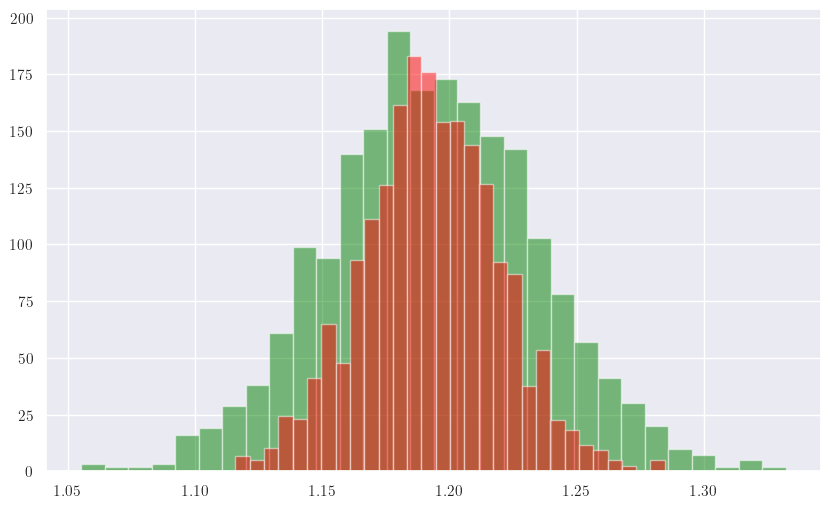

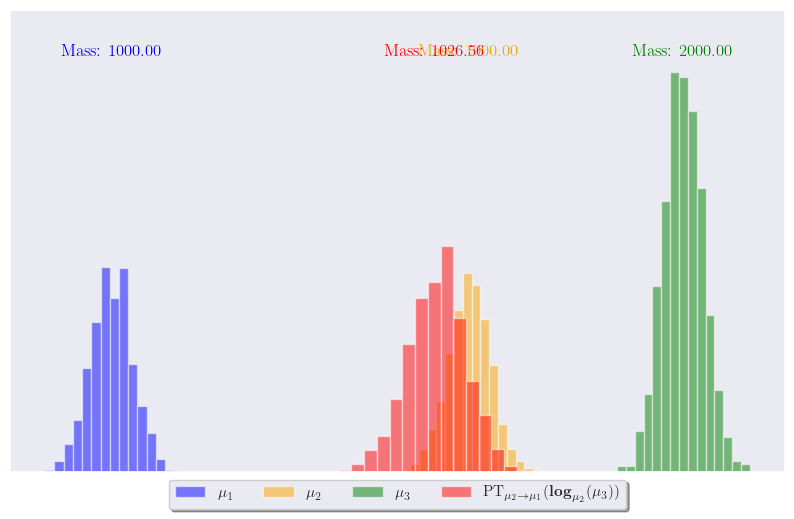

In [13]:
n_1 = 1000
n_2 = 1000
n_3 = 2000

mean_1 = np.array([0.0])
cov_1 = np.array([[2.0]])
mean_2 = np.array([25.0])
cov_2 = np.array([[2.0]])
mean_3 = np.array([40.0])
cov_3 = np.array([[2.0]])

data_1 = np.random.multivariate_normal(mean_1, cov_1, n_1)
data_2 = np.random.multivariate_normal(mean_2, cov_2, n_2)
data_3 = np.random.multivariate_normal(mean_3, cov_3, n_3)

# scale everything to < pi/4
max_val = max(np.max(data_1), np.max(data_2), np.max(data_3))
min_val = min(np.min(data_1), np.min(data_2), np.min(data_3))
scale_factor = ((np.pi / 2) - 1e-1) / (max_val - min_val)
data_1 *= scale_factor
data_2 *= scale_factor
data_3 *= scale_factor
# print(scaled means and covariances)
print(f"Scaled mean_1: {mean_1 * scale_factor}, Scaled sigma_1: {np.sqrt(cov_1[0, 0]) * scale_factor}")
print(f"Scaled mean_2: {mean_2 * scale_factor}, Scaled sigma_2: {np.sqrt(cov_2[0, 0]) * scale_factor}")
print(f"Scaled mean_3: {mean_3 * scale_factor}, Scaled sigma_3: {np.sqrt(cov_3[0, 0]) * scale_factor}")

mu1 = hkpt.EmpiricalMeasure(data_1, weights=np.ones(n_1))
mu2 = hkpt.EmpiricalMeasure(data_2, weights=np.ones(n_2))
mu3 = hkpt.EmpiricalMeasure(data_3, weights=np.ones(n_3))

tangent_23 = hkpt.hk_logarithmic_map(
    mu2,
    mu3, 
    allow_approximation=True, 
    approximation_mode='barycentric',
)

# diagnostic: plot mu3 and \hat mu3 = exp(log(mu2, mu3)) on the same plot
mu3_at_mu2 = hkpt.hk_exponential_map(mu2, tangent_23)
plt.figure(figsize=(10, 6))
plt.hist(data_3.flatten(), bins=30, weights=mu3.weights, label=r'$\mu_3$', color='green', alpha=0.5);
plt.hist(mu3_at_mu2.samples.flatten(), bins=30, weights=mu3_at_mu2.weights, label=r'$\hat{\mu}_3 = \exp_{\mu_2}(\log_{\mu2}(\mu_3))$', color='red', alpha=0.5);

# print mean and var of mu3 and mu3_at_mu2 locations (not weights)
print(f"mu3 mean: {np.mean(mu3.samples.flatten())}, mu3 var: {np.mean((mu3.samples.flatten() - np.mean(mu3.samples.flatten() ))**2 ) ** 0.5}")
print(f"mu3_at_mu2 mean: {np.mean(mu3_at_mu2.samples.flatten())}, mu3_at_mu2 var: {np.mean((mu3_at_mu2.samples.flatten() - np.mean(mu3_at_mu2.samples.flatten() ))**2 ) ** 0.5}")

# parallel transport tangent_23 from mu2 to mu1
tangent_23_at_mu1, pt_alignment_diag = hkpt.hk_parallel_transport(
    mu2,
    mu1,
    tangent_23,
    N = 4,
    return_alignment_diagnostics=True,
)

if pt_alignment_diag['alignment_succeeded']:
    print(f"Parallel transport alignment succeeded")
else:
    print(f"Parallel transport alignment failed with final alignment error {pt_alignment_diag['nearest_neighbor_distances'].max()}")

mu3_at_mu1 = hkpt.hk_exponential_map(mu1, tangent_23_at_mu1)

# plot all four measures on the same plot as unnormalized histograms with weights from the empirical measures
plt.figure(figsize=(10, 6))
plt.hist(data_1.flatten(), bins=15, weights=mu1.weights, label=r'$\mu_1$', color='blue', alpha=0.5);
plt.hist(data_2.flatten(), bins=15, weights=mu2.weights, label=r'$\mu_2$', color='orange', alpha=0.5);
plt.hist(data_3.flatten(), bins=15, weights=mu3.weights, label=r'$\mu_3$', color='green', alpha=0.5);
if mu3_at_mu1 is not None:
    plt.hist(mu3_at_mu1.samples.flatten(), bins=15, weights=mu3_at_mu1.weights, label=r'$\mathrm{PT}_{\mu_2 \rightarrow \mu_1}(\mathbf{log}_{\mu_2}(\mu_3))$', color='red', alpha=0.5);
# add legend underneath the plot
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.0),
    fancybox=True,
    shadow=True,
    ncol=4,
)
# no ticks
plt.xticks([]);
plt.yticks([]);
plt.ylim(0, plt.ylim()[1] * 1.1)
# add floating text at the mean of each distribution with total mass (sum of weights) in legend
x_mu1 = float(np.ravel(mean_1)[0]) * scale_factor
x_mu2 = float(np.ravel(mean_2)[0]) * scale_factor
x_mu3 = float(np.ravel(mean_3)[0]) * scale_factor
plt.text(x_mu1, plt.ylim()[1] * 0.9, f"Mass: {mu1.weights.sum():.2f}", color='blue', ha='center')
plt.text(x_mu2, plt.ylim()[1] * 0.9, f"Mass: {mu2.weights.sum():.2f}", color='orange', ha='center')
plt.text(x_mu3, plt.ylim()[1] * 0.9, f"Mass: {mu3.weights.sum():.2f}", color='green', ha='center')
if mu3_at_mu1 is not None:
    plt.text(np.mean(mu3_at_mu1.samples.flatten()), plt.ylim()[1] * 0.9, f"Mass: {mu3_at_mu1.weights.sum():.2f}", color='red', ha='center')
plt.savefig('../Figures/HK_parallel_transport_1d_mass_change.pdf', dpi=800)


# print means and variances of all measures
print(f"mu1 mean: {np.mean(mu1.samples.flatten())}, mu1 var: {np.mean((mu1.samples.flatten() - np.mean(mu1.samples.flatten() ))**2 ) ** 0.5}")
print(f"mu2 mean: {np.mean(mu2.samples.flatten())}, mu2 var: {np.mean((mu2.samples.flatten() - np.mean(mu2.samples.flatten() ))**2 ) ** 0.5}")
print(f"mu3 mean: {np.mean(mu3.samples.flatten())}, mu3 var: {np.mean((mu3.samples.flatten() - np.mean(mu3.samples.flatten() ))**2 ) ** 0.5}")
if mu3_at_mu1 is not None:
    print(f"mu3_at_mu1 mean: {np.mean(mu3_at_mu1.samples.flatten())}, mu3_at_mu1 var: {np.mean((mu3_at_mu1.samples.flatten() - np.mean(mu3_at_mu1.samples.flatten() ))**2 ) ** 0.5}")

# print mass of all measures
print(f"mu1 mass: {mu1.weights.sum()}")
print(f"mu2 mass: {mu2.weights.sum()}")
print(f"mu3 mass: {mu3.weights.sum()}")
if mu3_at_mu1 is not None:
    print(f"mu3_at_mu1 mass: {mu3_at_mu1.weights.sum()}")

# print HK distance between mu1 and mu3, and between mu1 and mu3_at_mu1
hk_distance_mu2_mu3 = hkpt.hk_distance(mu2, mu3)
hk_distance_mu1_mu3_at_mu1 = hkpt.hk_distance(mu1, mu3_at_mu1)
print(f"HK distance between mu2 and mu3: {hk_distance_mu2_mu3}")
print(f"HK distance between mu1 and mu3_at_mu1: {hk_distance_mu1_mu3_at_mu1}")

Scaled mean_1: [0.], Scaled sigma_1: 0.21846472019805452
Scaled mean_2: [0.], Scaled sigma_2: 0.21846472019805452
Scaled mean_3: [0.], Scaled sigma_3: 0.21846472019805452
Transporting step 1/4...
Transporting step 2/4...
Transporting step 3/4...
Transporting step 4/4...
Parallel transport alignment succeeded
mu1 mean: 0.029566414429505364, mu1 var: 0.21417115196192643
mu2 mean: 0.003718161176909183, mu2 var: 0.22245419597015859
mu3 mean: 0.0012230707586024128, mu3 var: 0.21500138675131755
mu4_at_mu3 mean: -0.010190807892164463, mu4_at_mu3 var: 0.2126838076789608
mu1 mass: 500.0
mu2 mass: 1000.0
mu3 mass: 1000.0
mu4_at_mu3 mass: 1666.703845523266
HK distance between mu1 and mu2: 9.368742205305578
HK distance between mu3 and mu4_at_mu3: 9.350702092214293


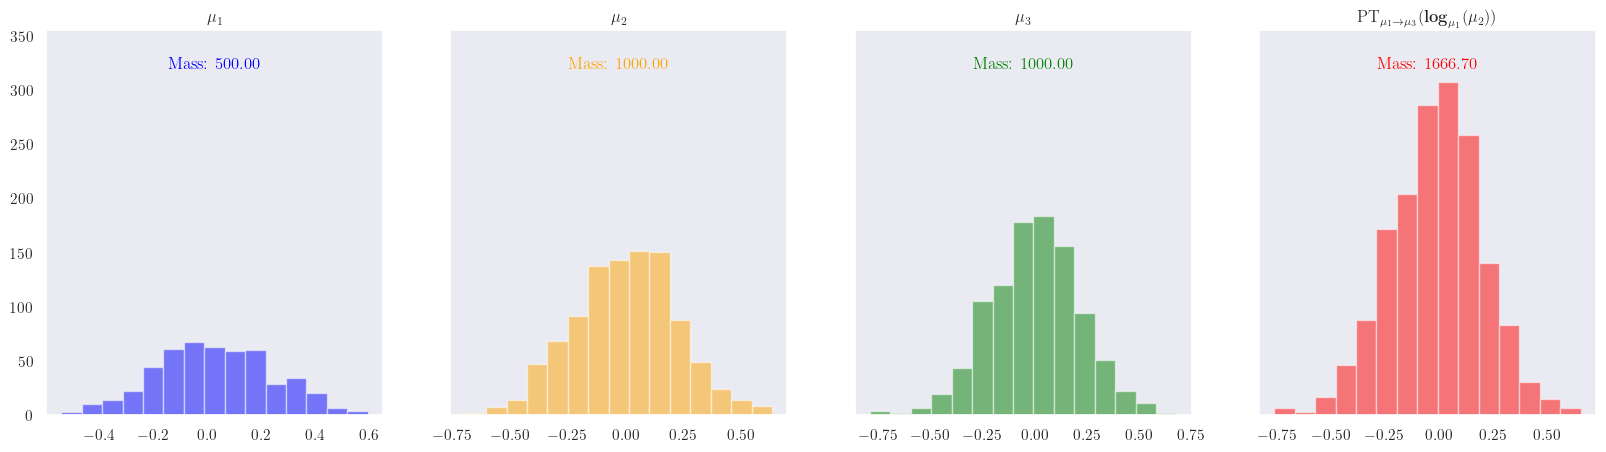

In [25]:
n_1 = 500
n_2 = 1000
n_3 = 1000

mean_1 = np.array([0.0])
cov_1 = np.array([[2.0]])
mean_2 = np.array([0.0])
cov_2 = np.array([[2.0]])
mean_3 = np.array([0.0])
cov_3 = np.array([[2.0]])

data_1 = np.random.multivariate_normal(mean_1, cov_1, n_1)
data_2 = np.random.multivariate_normal(mean_2, cov_2, n_2)
data_3 = np.random.multivariate_normal(mean_3, cov_3, n_3)

# scale everything to < pi/4
max_val = max(np.max(data_1), np.max(data_2), np.max(data_3))
min_val = min(np.min(data_1), np.min(data_2), np.min(data_3))
scale_factor = ((np.pi / 2) - 1e-1) / (max_val - min_val)
data_1 *= scale_factor
data_2 *= scale_factor
data_3 *= scale_factor
# print(scaled means and covariances)
print(f"Scaled mean_1: {mean_1 * scale_factor}, Scaled sigma_1: {np.sqrt(cov_1[0, 0]) * scale_factor}")
print(f"Scaled mean_2: {mean_2 * scale_factor}, Scaled sigma_2: {np.sqrt(cov_2[0, 0]) * scale_factor}")
print(f"Scaled mean_3: {mean_3 * scale_factor}, Scaled sigma_3: {np.sqrt(cov_3[0, 0]) * scale_factor}")

mu1 = hkpt.EmpiricalMeasure(data_1, weights=np.ones(n_1))
mu2 = hkpt.EmpiricalMeasure(data_2, weights=np.ones(n_2))
mu3 = hkpt.EmpiricalMeasure(data_3, weights=np.ones(n_3))

tangent_12 = hkpt.hk_logarithmic_map(
    mu1,
    mu2, 
    allow_approximation=True, 
    approximation_mode='barycentric',
)


# parallel transport tangent_12 from mu1 to mu3
tangent_12_at_mu3, pt_alignment_diag = hkpt.hk_parallel_transport(
    mu1,
    mu3,
    tangent_12,
    N = 4,
    return_alignment_diagnostics=True,
)

if pt_alignment_diag['alignment_succeeded']:
    print(f"Parallel transport alignment succeeded")
else:
    print(f"Parallel transport alignment failed with final alignment error {pt_alignment_diag['nearest_neighbor_distances'].max()}")

mu4_at_mu3 = hkpt.hk_exponential_map(mu3, tangent_12_at_mu3)

# plot all four measures on the four different subplots in one row as unnormalized histograms with weights from the empirical measures
fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
axs[0].hist(data_1.flatten(), bins=15, weights=mu1.weights, label=r'$\mu_1$', color='blue', alpha=0.5);
axs[0].set_title(r'$\mu_1$')
axs[1].hist(data_2.flatten(), bins=15, weights=mu2.weights, label=r'$\mu_2$', color='orange', alpha=0.5);
axs[1].set_title(r'$\mu_2$')
axs[2].hist(data_3.flatten(), bins=15, weights=mu3.weights, label=r'$\mu_3$', color='green', alpha=0.5);
axs[2].set_title(r'$\mu_3$')
if mu4_at_mu3 is not None:
    axs[3].hist(mu4_at_mu3.samples.flatten(), bins=15, weights=mu4_at_mu3.weights, label=r'$\mathrm{PT}_{\mu_1 \rightarrow \mu_3}(\mathbf{log}_{\mu_1}(\mu_2))$', color='red', alpha=0.5);
    axs[3].set_title(r'$\mathrm{PT}_{\mu_1 \rightarrow \mu_3}(\mathbf{log}_{\mu_1}(\mu_2))$')
# increase ylim a bit
plt.ylim(0, plt.ylim()[1] * 1.1)

# print means and variances of all measures
print(f"mu1 mean: {np.mean(mu1.samples.flatten())}, mu1 var: {np.mean((mu1.samples.flatten() - np.mean(mu1.samples.flatten() ))**2 ) ** 0.5}")
print(f"mu2 mean: {np.mean(mu2.samples.flatten())}, mu2 var: {np.mean((mu2.samples.flatten() - np.mean(mu2.samples.flatten() ))**2 ) ** 0.5}")
print(f"mu3 mean: {np.mean(mu3.samples.flatten())}, mu3 var: {np.mean((mu3.samples.flatten() - np.mean(mu3.samples.flatten() ))**2 ) ** 0.5}")
if mu4_at_mu3 is not None:
    print(f"mu4_at_mu3 mean: {np.mean(mu4_at_mu3.samples.flatten())}, mu4_at_mu3 var: {np.mean((mu4_at_mu3.samples.flatten() - np.mean(mu4_at_mu3.samples.flatten() ))**2 ) ** 0.5}")

# add text to each subplot with the mass (sum of weights) of each measure
axs[0].text(0.5, 0.9, f"Mass: {mu1.weights.sum():.2f}", transform=axs[0].transAxes, color='blue', ha='center')
axs[1].text(0.5, 0.9, f"Mass: {mu2.weights.sum():.2f}", transform=axs[1].transAxes, color='orange', ha='center')
axs[2].text(0.5, 0.9, f"Mass: {mu3.weights.sum():.2f}", transform=axs[2].transAxes, color='green', ha='center')
if mu4_at_mu3 is not None:
    axs[3].text(0.5, 0.9, f"Mass: {mu4_at_mu3.weights.sum():.2f}", transform=axs[3].transAxes, color='red', ha='center')

# get rid of grid lines
for ax in axs:
    ax.grid(False)

# save figure
plt.savefig('../Figures/HK_parallel_transport_1d_mass_increase_no_mean_shift.pdf', dpi=800)

# print mass of all measures
print(f"mu1 mass: {mu1.weights.sum()}")
print(f"mu2 mass: {mu2.weights.sum()}")
print(f"mu3 mass: {mu3.weights.sum()}")
if mu4_at_mu3 is not None:
    print(f"mu4_at_mu3 mass: {mu4_at_mu3.weights.sum()}")

# print HK distance between mu1 and mu3, and between mu1 and mu3_at_mu1
hk_distance_mu1_mu2 = hkpt.hk_distance(mu1, mu2)
hk_distance_mu3_mu4_at_mu3 = hkpt.hk_distance(mu3, mu4_at_mu3)
print(f"HK distance between mu1 and mu2: {hk_distance_mu1_mu2}")
print(f"HK distance between mu3 and mu4_at_mu3: {hk_distance_mu3_mu4_at_mu3}")


Scaled mean_1: [0.], Scaled sigma_1: 0.21907717172029828
Scaled mean_2: [0.], Scaled sigma_2: 0.21907717172029828
Scaled mean_3: [0.], Scaled sigma_3: 0.21907717172029828
Transporting step 1/4...
Transporting step 2/4...
Transporting step 3/4...
Transporting step 4/4...
Parallel transport alignment succeeded
mu1 mean: 0.009470277762006098, mu1 var: 0.22099986437994498
mu2 mean: -0.00205410181277023, mu2 var: 0.21724304554285154
mu3 mean: 0.00221759943254214, mu3 var: 0.21345391993235158
mu4_at_mu3 mean: -0.005552500329353801, mu4_at_mu3 var: 0.2116634783812267
mu1 mass: 1000.0
mu2 mass: 500.0
mu3 mass: 2000.0
mu4_at_mu3 mass: 1258.7960461517532
HK distance between mu1 and mu2: 9.349420808110892
HK distance between mu3 and mu4_at_mu3: 9.420761091144964


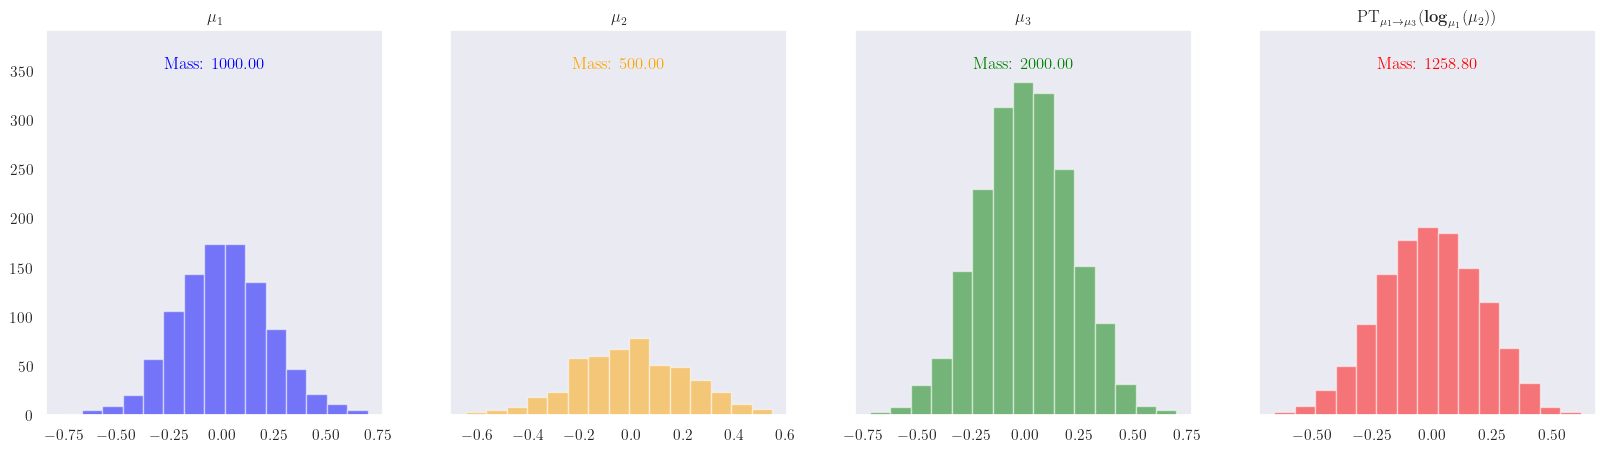

In [26]:
n_1 = 1000
n_2 = 500
n_3 = 2000

mean_1 = np.array([0.0])
cov_1 = np.array([[2.0]])
mean_2 = np.array([0.0])
cov_2 = np.array([[2.0]])
mean_3 = np.array([0.0])
cov_3 = np.array([[2.0]])

data_1 = np.random.multivariate_normal(mean_1, cov_1, n_1)
data_2 = np.random.multivariate_normal(mean_2, cov_2, n_2)
data_3 = np.random.multivariate_normal(mean_3, cov_3, n_3)

# scale everything to < pi/4
max_val = max(np.max(data_1), np.max(data_2), np.max(data_3))
min_val = min(np.min(data_1), np.min(data_2), np.min(data_3))
scale_factor = ((np.pi / 2) - 1e-1) / (max_val - min_val)
data_1 *= scale_factor
data_2 *= scale_factor
data_3 *= scale_factor
# print(scaled means and covariances)
print(f"Scaled mean_1: {mean_1 * scale_factor}, Scaled sigma_1: {np.sqrt(cov_1[0, 0]) * scale_factor}")
print(f"Scaled mean_2: {mean_2 * scale_factor}, Scaled sigma_2: {np.sqrt(cov_2[0, 0]) * scale_factor}")
print(f"Scaled mean_3: {mean_3 * scale_factor}, Scaled sigma_3: {np.sqrt(cov_3[0, 0]) * scale_factor}")

mu1 = hkpt.EmpiricalMeasure(data_1, weights=np.ones(n_1))
mu2 = hkpt.EmpiricalMeasure(data_2, weights=np.ones(n_2))
mu3 = hkpt.EmpiricalMeasure(data_3, weights=np.ones(n_3))

tangent_12 = hkpt.hk_logarithmic_map(
    mu1,
    mu2, 
    allow_approximation=True, 
    approximation_mode='barycentric',
)


# parallel transport tangent_12 from mu1 to mu3
tangent_12_at_mu3, pt_alignment_diag = hkpt.hk_parallel_transport(
    mu1,
    mu3,
    tangent_12,
    N = 4,
    return_alignment_diagnostics=True,
)

if pt_alignment_diag['alignment_succeeded']:
    print(f"Parallel transport alignment succeeded")
else:
    print(f"Parallel transport alignment failed with final alignment error {pt_alignment_diag['nearest_neighbor_distances'].max()}")

mu4_at_mu3 = hkpt.hk_exponential_map(mu3, tangent_12_at_mu3)

# plot all four measures on the four different subplots in one row as unnormalized histograms with weights from the empirical measures
fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
axs[0].hist(data_1.flatten(), bins=15, weights=mu1.weights, label=r'$\mu_1$', color='blue', alpha=0.5);
axs[0].set_title(r'$\mu_1$')
axs[1].hist(data_2.flatten(), bins=15, weights=mu2.weights, label=r'$\mu_2$', color='orange', alpha=0.5);
axs[1].set_title(r'$\mu_2$')
axs[2].hist(data_3.flatten(), bins=15, weights=mu3.weights, label=r'$\mu_3$', color='green', alpha=0.5);
axs[2].set_title(r'$\mu_3$')
if mu4_at_mu3 is not None:
    axs[3].hist(mu4_at_mu3.samples.flatten(), bins=15, weights=mu4_at_mu3.weights, label=r'$\mathrm{PT}_{\mu_1 \rightarrow \mu_3}(\mathbf{log}_{\mu_1}(\mu_2))$', color='red', alpha=0.5);
    axs[3].set_title(r'$\mathrm{PT}_{\mu_1 \rightarrow \mu_3}(\mathbf{log}_{\mu_1}(\mu_2))$')
# increase ylim a bit
plt.ylim(0, plt.ylim()[1] * 1.1)

# print means and variances of all measures
print(f"mu1 mean: {np.mean(mu1.samples.flatten())}, mu1 var: {np.mean((mu1.samples.flatten() - np.mean(mu1.samples.flatten() ))**2 ) ** 0.5}")
print(f"mu2 mean: {np.mean(mu2.samples.flatten())}, mu2 var: {np.mean((mu2.samples.flatten() - np.mean(mu2.samples.flatten() ))**2 ) ** 0.5}")
print(f"mu3 mean: {np.mean(mu3.samples.flatten())}, mu3 var: {np.mean((mu3.samples.flatten() - np.mean(mu3.samples.flatten() ))**2 ) ** 0.5}")
if mu4_at_mu3 is not None:
    print(f"mu4_at_mu3 mean: {np.mean(mu4_at_mu3.samples.flatten())}, mu4_at_mu3 var: {np.mean((mu4_at_mu3.samples.flatten() - np.mean(mu4_at_mu3.samples.flatten() ))**2 ) ** 0.5}")

# add text to each subplot with the mass (sum of weights) of each measure
axs[0].text(0.5, 0.9, f"Mass: {mu1.weights.sum():.2f}", transform=axs[0].transAxes, color='blue', ha='center')
axs[1].text(0.5, 0.9, f"Mass: {mu2.weights.sum():.2f}", transform=axs[1].transAxes, color='orange', ha='center')
axs[2].text(0.5, 0.9, f"Mass: {mu3.weights.sum():.2f}", transform=axs[2].transAxes, color='green', ha='center')
if mu4_at_mu3 is not None:
    axs[3].text(0.5, 0.9, f"Mass: {mu4_at_mu3.weights.sum():.2f}", transform=axs[3].transAxes, color='red', ha='center')

# get rid of grid lines
for ax in axs:
    ax.grid(False)

# save figure
plt.savefig('../Figures/HK_parallel_transport_1d_mass_decrease_no_mean_shift.pdf', dpi=800)


# print mass of all measures
print(f"mu1 mass: {mu1.weights.sum()}")
print(f"mu2 mass: {mu2.weights.sum()}")
print(f"mu3 mass: {mu3.weights.sum()}")
if mu4_at_mu3 is not None:
    print(f"mu4_at_mu3 mass: {mu4_at_mu3.weights.sum()}")

# print HK distance between mu1 and mu3, and between mu1 and mu3_at_mu1
hk_distance_mu1_mu2 = hkpt.hk_distance(mu1, mu2)
hk_distance_mu3_mu4_at_mu3 = hkpt.hk_distance(mu3, mu4_at_mu3)
print(f"HK distance between mu1 and mu2: {hk_distance_mu1_mu2}")
print(f"HK distance between mu3 and mu4_at_mu3: {hk_distance_mu3_mu4_at_mu3}")


Transporting step 1/5...
Transporting step 2/5...
Transporting step 3/5...
Transporting step 4/5...
Transporting step 5/5...


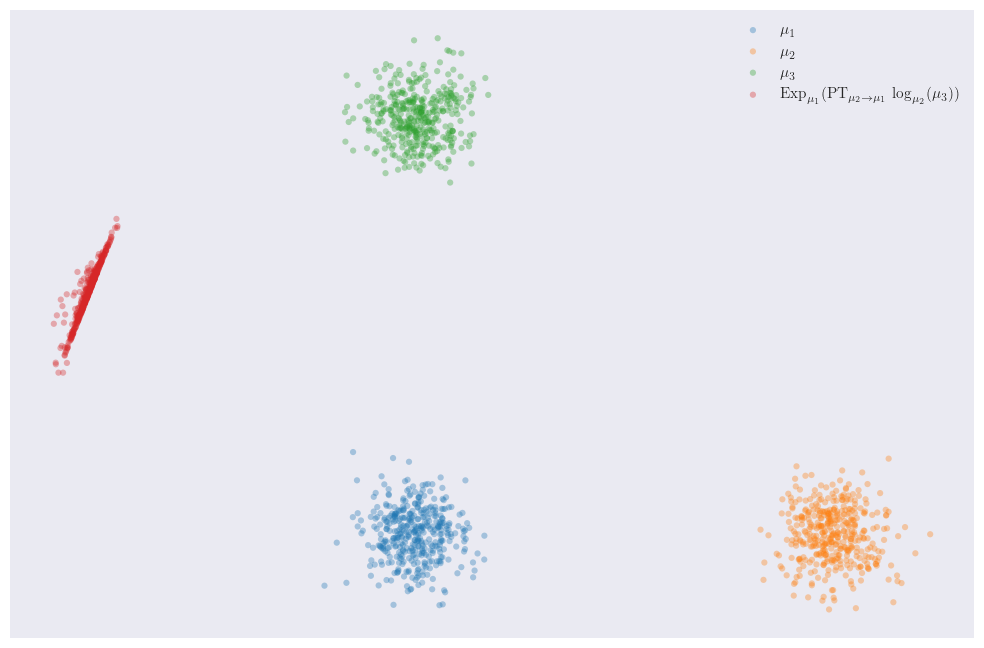

In [27]:
# 2D Gaussian experiment: parallel transport mu3 to the tangent space at mu1,
# then push forward with the empirical HK exponential map.
n_1_2d = 400
n_2_2d = 400
n_3_2d = 400

mean_1_2d = np.array([0.0, 0.0])
cov_1_2d = np.array([[0.1, 0.0], [0.0, 0.1]])
mean_2_2d = np.array([5.0, 0.0])
cov_2_2d = np.array([[0.1, 0.0], [0.0, 0.1]])
mean_3_2d = np.array([0.0, 5.0])
cov_3_2d = np.array([[0.1, 0.0], [0.0, 0.1]])

rng_2d = np.random.default_rng(1)
data_1_2d = rng_2d.multivariate_normal(mean_1_2d, cov_1_2d, n_1_2d)
data_2_2d = rng_2d.multivariate_normal(mean_2_2d, cov_2_2d, n_2_2d)
data_3_2d = rng_2d.multivariate_normal(mean_3_2d, cov_3_2d, n_3_2d)

# Scale all samples so pairwise distances stay comfortably inside the HK cone regime.
all_data_2d = np.vstack([data_1_2d, data_2_2d, data_3_2d])
pwise_distances = np.linalg.norm(all_data_2d[:, None, :] - all_data_2d[None, :, :], axis=-1)
max_radius_2d = np.max(pwise_distances)
scale_factor_2d = ((np.pi / 2) - 1e-1) / max_radius_2d
data_1_2d *= scale_factor_2d
data_2_2d *= scale_factor_2d
data_3_2d *= scale_factor_2d

mu1_2d = hkpt.EmpiricalMeasure(data_1_2d, weights=np.ones(n_1_2d))
mu2_2d = hkpt.EmpiricalMeasure(data_2_2d, weights=np.ones(n_2_2d))
mu3_2d = hkpt.EmpiricalMeasure(data_3_2d, weights=np.ones(n_3_2d))

tangent_23_2d = hkpt.hk_logarithmic_map(
    mu2_2d,
    mu3_2d,
    allow_approximation=True,
    approximation_mode='barycentric',
)

tangent_23_at_mu1_2d, pt_alignment_diag_2d = hkpt.hk_parallel_transport(
    mu2_2d,
    mu1_2d,
    tangent_23_2d,
    return_alignment_diagnostics=True,
    N = 5,
)

if tangent_23_at_mu1_2d is not None:
    mu3_at_mu1_2d = hkpt.hk_exponential_map(mu1_2d, tangent_23_at_mu1_2d)
else:
    mu3_at_mu1_2d = hkpt.EmpiricalMeasure(
        pt_alignment_diag_2d['transported_support'],
        np.ones(len(pt_alignment_diag_2d['transported_support'])),
    )

measures_2d = [
    (mu1_2d, r'$\mu_1$', '#1f77b4'),
    (mu2_2d, r'$\mu_2$', '#ff7f0e'),
    (mu3_2d, r'$\mu_3$', '#2ca02c'),
    (mu3_at_mu1_2d, r'$\mathrm{Exp}_{\mu_1}(\mathrm{PT}_{\mu_2\to\mu_1}\,\log_{\mu_2}(\mu_3))$', '#d62728'),
]

fig, ax = plt.subplots(figsize=(10, 8))
for measure, label, color in measures_2d:
    ax.scatter(
        measure.samples[:, 0],
        measure.samples[:, 1],
        s=20,
        alpha=0.35,
        color=color,
        edgecolors='none',
        label=label,
    )

# ax.set_xlabel(r'$x_1$')
# ax.set_ylabel(r'$x_2$')
# get rid of ticks and axis lines
ax.set_xticks([])
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False) 
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.set_aspect('equal', adjustable='box')
ax.legend(frameon=False)

if not pt_alignment_diag_2d['alignment_succeeded']:
    ax.set_title('2D HK experiment (red cloud uses transported support; final alignment failed)')

plt.tight_layout()
plt.show()


Scaled mean_1: [0.], Scaled sigma_1: 0.042578062366987614
Scaled mean_2: [0.75268092], Scaled sigma_2: 0.042578062366987614
Scaled mean_3: [1.20428947], Scaled sigma_3: 0.042578062366987614
mu3 mean: 1.2023377741264734, mu3 var: 0.043215663291237015
mu3_at_mu2 mean: 1.1999145271690126, mu3_at_mu2 var: 0.028262232872905094
Transporting step 1/4...
Transporting step 2/4...
Transporting step 3/4...
Transporting step 4/4...
Parallel transport alignment succeeded
HK distance between mu2 and mu3: 19.90247729832277
HK distance between mu1 and mu3_at_mu1: 19.83904113385977
Scaled mean_1: [0.], Scaled sigma_1: 0.042578062366987614
Scaled mean_2: [0.75268092], Scaled sigma_2: 0.042578062366987614
Scaled mean_3: [1.20428947], Scaled sigma_3: 0.042578062366987614
mu3 mean: 1.2023377741264734, mu3 var: 0.043215663291237015
mu3_at_mu2 mean: 1.2023017638708515, mu3_at_mu2 var: 0.0016054439181116033
Transporting step 1/4...
Transporting step 2/4...
Transporting step 3/4...
Transporting step 4/4...
Par

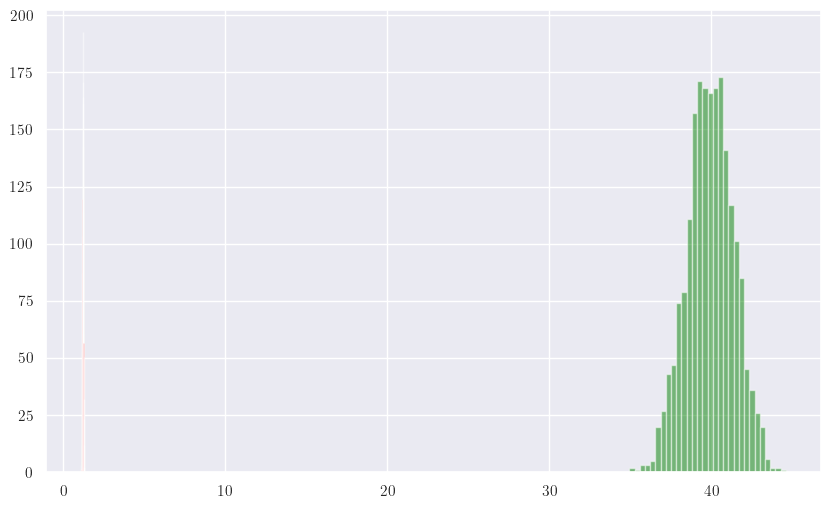

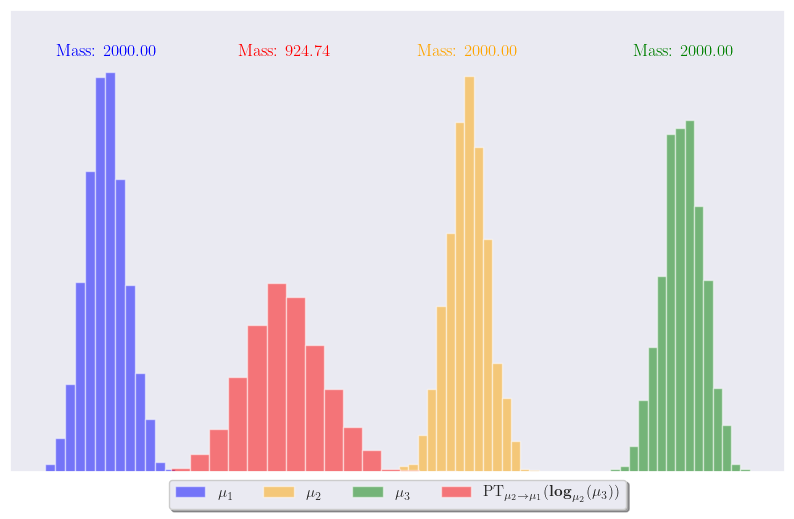

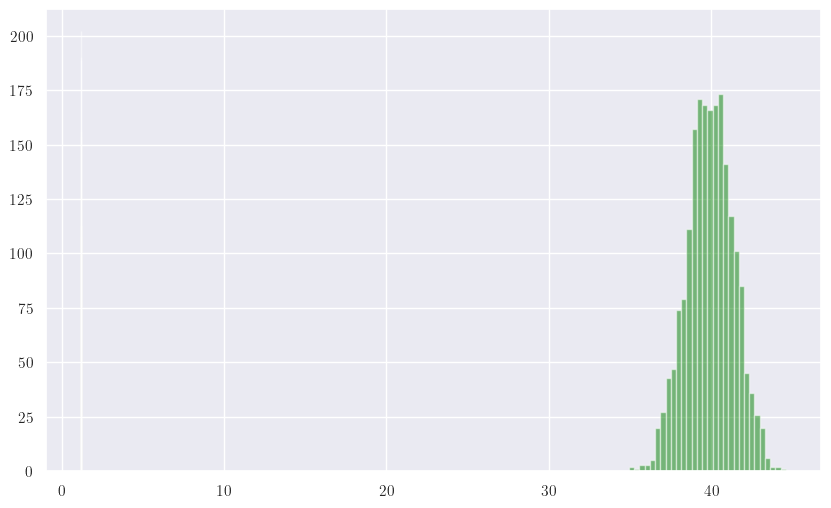

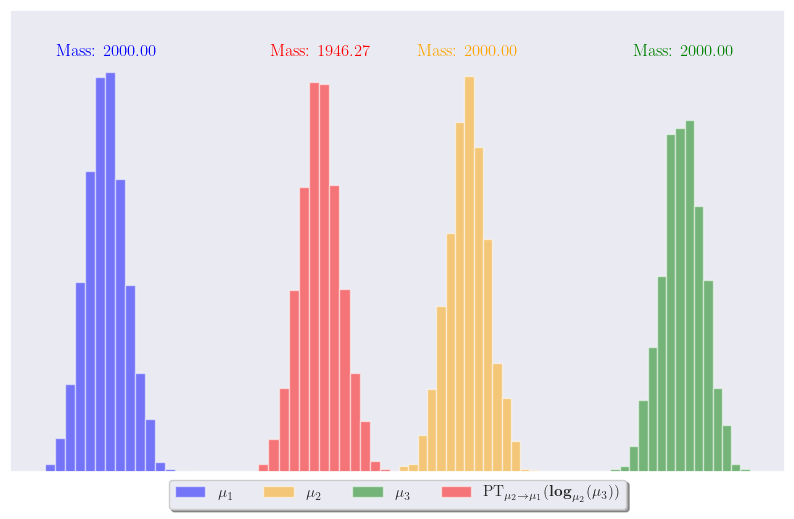

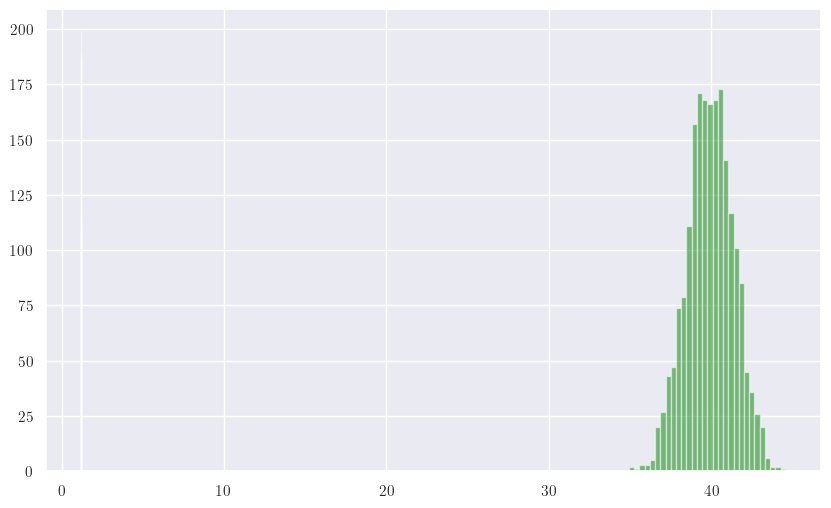

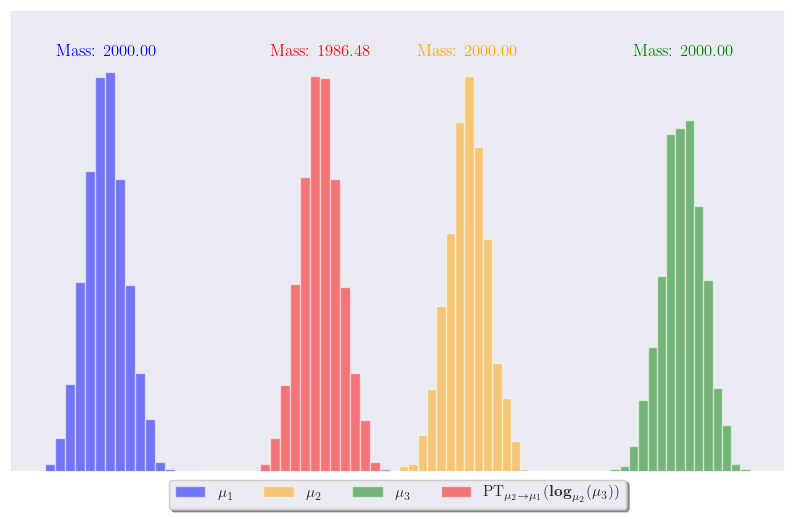

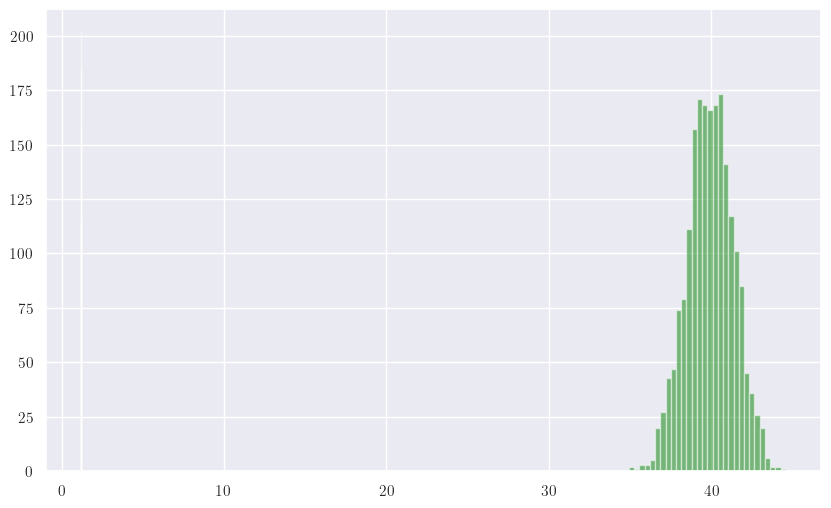

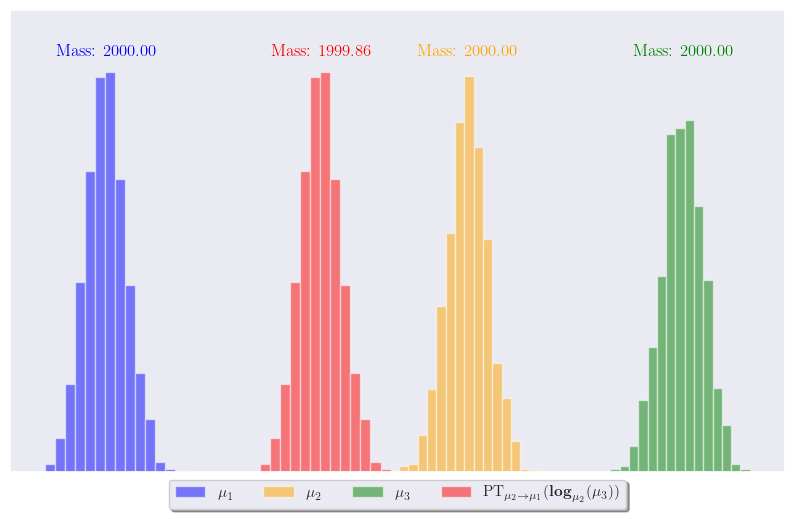

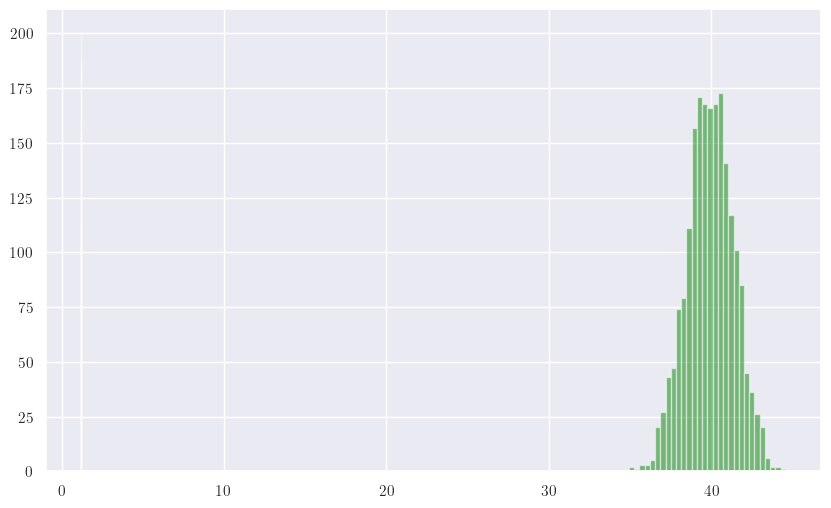

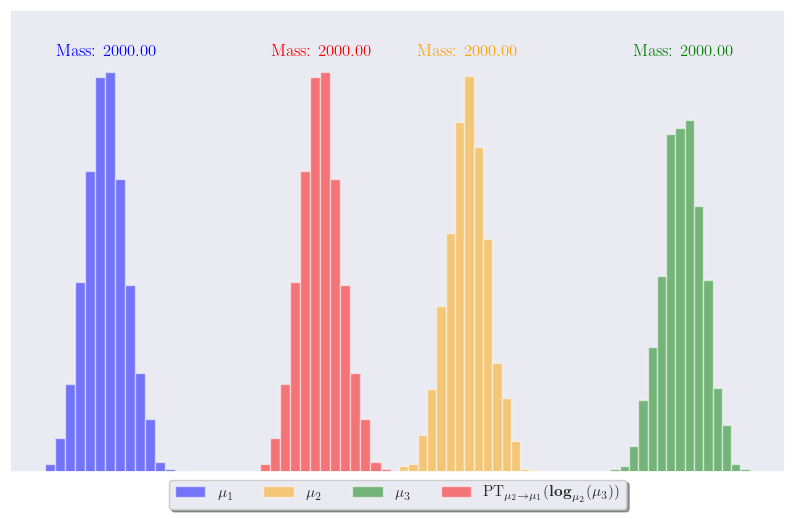

In [33]:
n_1 = 2000
n_2 = 2000
n_3 = 2000

ldas = [1, 5, 10, 100, 1000]

mean_1 = np.array([0.0])
cov_1 = np.array([[2.0]])
mean_2 = np.array([25.0])
cov_2 = np.array([[2.0]])
mean_3 = np.array([40.0])
cov_3 = np.array([[2.0]])

data_1 = np.random.multivariate_normal(mean_1, cov_1, n_1)
data_2 = np.random.multivariate_normal(mean_2, cov_2, n_2)
data_3 = np.random.multivariate_normal(mean_3, cov_3, n_3)

# scale everything to < pi/4
max_val = max(np.max(data_1), np.max(data_2), np.max(data_3))
min_val = min(np.min(data_1), np.min(data_2), np.min(data_3))
scale_factor = ((np.pi / 2) - 1e-1) / (max_val - min_val)

for lda in ldas:
    data_1_scaled = data_1 * scale_factor
    data_2_scaled = data_2 * scale_factor
    data_3_scaled = data_3 * scale_factor
    # print(scaled means and covariances)
    print(f"Scaled mean_1: {mean_1 * scale_factor}, Scaled sigma_1: {np.sqrt(cov_1[0, 0]) * scale_factor}")
    print(f"Scaled mean_2: {mean_2 * scale_factor}, Scaled sigma_2: {np.sqrt(cov_2[0, 0]) * scale_factor}")
    print(f"Scaled mean_3: {mean_3 * scale_factor}, Scaled sigma_3: {np.sqrt(cov_3[0, 0]) * scale_factor}")

    mu1 = hkpt.EmpiricalMeasure(data_1_scaled, weights=np.ones(n_1))
    mu2 = hkpt.EmpiricalMeasure(data_2_scaled, weights=np.ones(n_2))
    mu3 = hkpt.EmpiricalMeasure(data_3_scaled, weights=np.ones(n_3))

    tangent_23 = hkpt.hk_logarithmic_map(
        mu2,
        mu3, 
        allow_approximation=True, 
        approximation_mode='barycentric',
        scale=lda,
    )

    # diagnostic: plot mu3 and \hat mu3 = exp(log(mu2, mu3)) on the same plot
    mu3_at_mu2 = hkpt.hk_exponential_map(mu2, tangent_23, scale=lda)
    plt.figure(figsize=(10, 6))
    plt.hist(data_3.flatten(), bins=30, weights=mu3.weights, label=r'$\mu_3$', color='green', alpha=0.5);
    plt.hist(mu3_at_mu2.samples.flatten(), bins=30, weights=mu3_at_mu2.weights, label=r'$\hat{\mu}_3 = \exp_{\mu_2}(\log_{\mu2}(\mu_3))$', color='red', alpha=0.5);

    # print mean and var of mu3 and mu3_at_mu2 locations (not weights)
    print(f"mu3 mean: {np.mean(mu3.samples.flatten())}, mu3 var: {np.mean((mu3.samples.flatten() - np.mean(mu3.samples.flatten() ))**2 ) ** 0.5}")
    print(f"mu3_at_mu2 mean: {np.mean(mu3_at_mu2.samples.flatten())}, mu3_at_mu2 var: {np.mean((mu3_at_mu2.samples.flatten() - np.mean(mu3_at_mu2.samples.flatten() ))**2 ) ** 0.5}")

    # parallel transport tangent_23 from mu2 to mu1
    tangent_23_at_mu1, pt_alignment_diag = hkpt.hk_parallel_transport(
        mu2,
        mu1,
        tangent_23,
        N = 4,
        return_alignment_diagnostics=True,
        scale=lda,
    )

    if pt_alignment_diag['alignment_succeeded']:
        print(f"Parallel transport alignment succeeded")
    else:
        print(f"Parallel transport alignment failed with final alignment error {pt_alignment_diag['nearest_neighbor_distances'].max()}")

    mu3_at_mu1 = hkpt.hk_exponential_map(mu1, tangent_23_at_mu1, scale=lda)

    # plot all four measures on the same plot as unnormalized histograms with weights from the empirical measures
    plt.figure(figsize=(10, 6))
    plt.hist(data_1_scaled.flatten(), bins=15, weights=mu1.weights, label=r'$\mu_1$', color='blue', alpha=0.5);
    plt.hist(data_2_scaled.flatten(), bins=15, weights=mu2.weights, label=r'$\mu_2$', color='orange', alpha=0.5);
    plt.hist(data_3_scaled.flatten(), bins=15, weights=mu3.weights, label=r'$\mu_3$', color='green', alpha=0.5);
    if mu3_at_mu1 is not None:
        plt.hist(mu3_at_mu1.samples.flatten(), bins=15, weights=mu3_at_mu1.weights, label=r'$\mathrm{PT}_{\mu_2 \rightarrow \mu_1}(\mathbf{log}_{\mu_2}(\mu_3))$', color='red', alpha=0.5);
    # add legend underneath the plot
    plt.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.0),
        fancybox=True,
        shadow=True,
        ncol=4,
    )
    # no ticks
    plt.xticks([]);
    plt.yticks([]);
    plt.ylim(0, plt.ylim()[1] * 1.1)
    # add floating text at the mean of each distribution with total mass (sum of weights) in legend
    x_mu1 = float(np.ravel(mean_1)[0]) * scale_factor
    x_mu2 = float(np.ravel(mean_2)[0]) * scale_factor
    x_mu3 = float(np.ravel(mean_3)[0]) * scale_factor
    plt.text(x_mu1, plt.ylim()[1] * 0.9, f"Mass: {mu1.weights.sum():.2f}", color='blue', ha='center')
    plt.text(x_mu2, plt.ylim()[1] * 0.9, f"Mass: {mu2.weights.sum():.2f}", color='orange', ha='center')
    plt.text(x_mu3, plt.ylim()[1] * 0.9, f"Mass: {mu3.weights.sum():.2f}", color='green', ha='center')
    if mu3_at_mu1 is not None:
        plt.text(np.mean(mu3_at_mu1.samples.flatten()), plt.ylim()[1] * 0.9, f"Mass: {mu3_at_mu1.weights.sum():.2f}", color='red', ha='center')
    plt.savefig(f'../Figures/HK_parallel_transport_1d_mean_shift_scale_{lda}.pdf', dpi=800)

    # print HK distance between mu1 and mu3, and between mu1 and mu3_at_mu1
    hk_distance_mu2_mu3 = hkpt.hk_distance(mu2, mu3, scale=lda)
    hk_distance_mu1_mu3_at_mu1 = hkpt.hk_distance(mu1, mu3_at_mu1, scale=lda)
    print(f"HK distance between mu2 and mu3: {hk_distance_mu2_mu3}")
    print(f"HK distance between mu1 and mu3_at_mu1: {hk_distance_mu1_mu3_at_mu1}")



Scaled mean_1: [0.], Scaled sigma_1: 0.10242347725825333
Scaled mean_2: [0.], Scaled sigma_2: 0.14484867064403412
Scaled mean_3: [0.], Scaled sigma_3: 0.20484695451650667


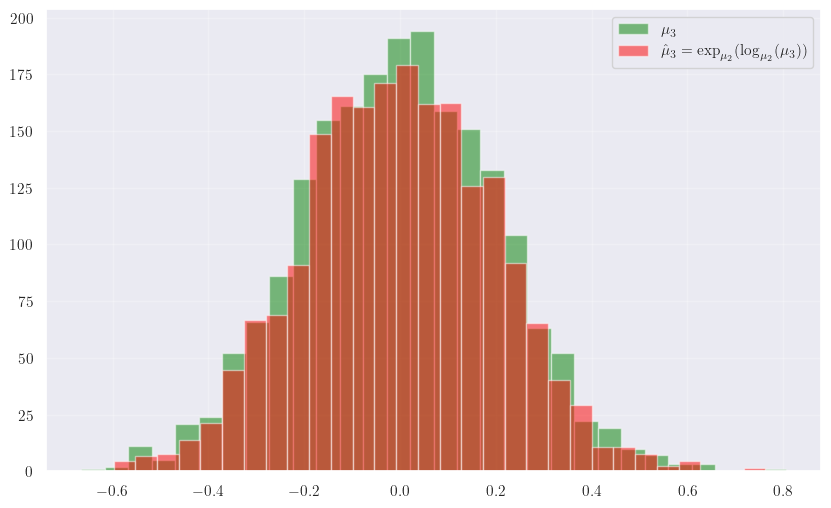

mu3 mean: -0.0006810337685586503, mu3 var: 0.20376304999336545
mu3_at_mu2 mean: -0.000777296735309569, mu3_at_mu2 var: 0.19331756156237173
Transporting step 1/4...
Transporting step 2/4...
Transporting step 3/4...
Transporting step 4/4...
Parallel transport alignment succeeded


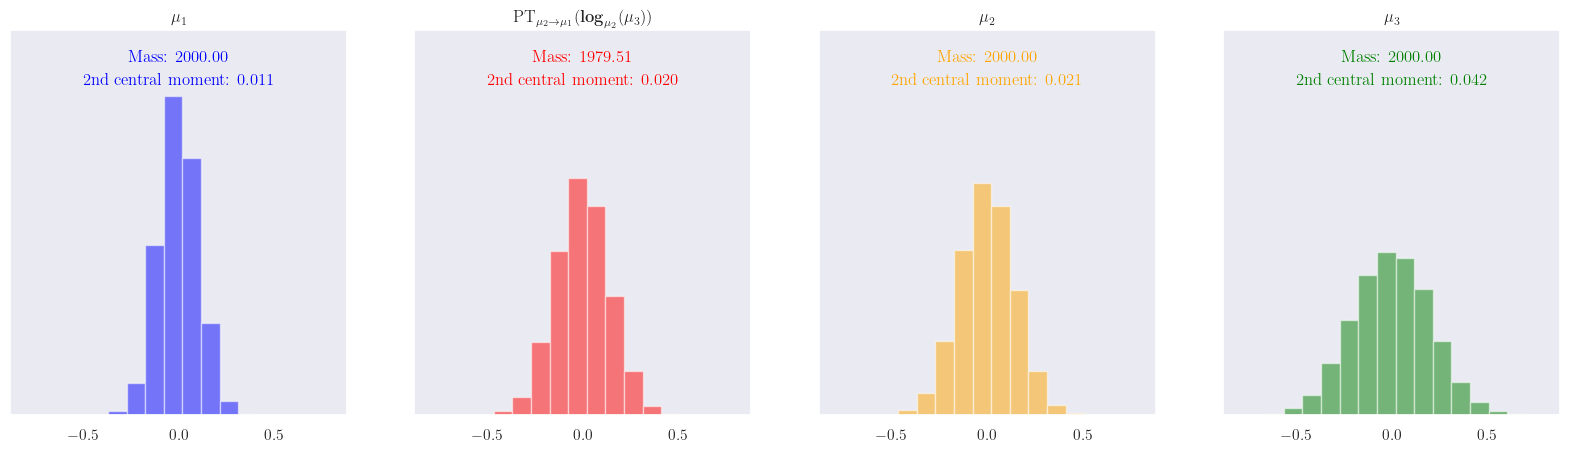

HK distance between mu2 and mu3: 3.23867330925286
HK distance between mu1 and mu3_at_mu1: 2.6277595626102985


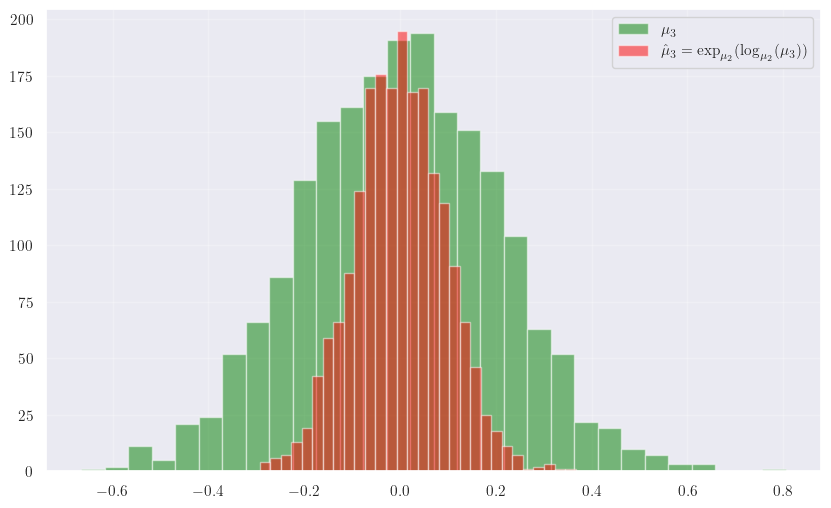

mu3 mean: -0.0006810337685586503, mu3 var: 0.20376304999336545
mu3_at_mu2 mean: -0.0006845036514088557, mu3_at_mu2 var: 0.09445008788908534
Transporting step 1/4...
Transporting step 2/4...
Transporting step 3/4...
Transporting step 4/4...
Parallel transport alignment succeeded


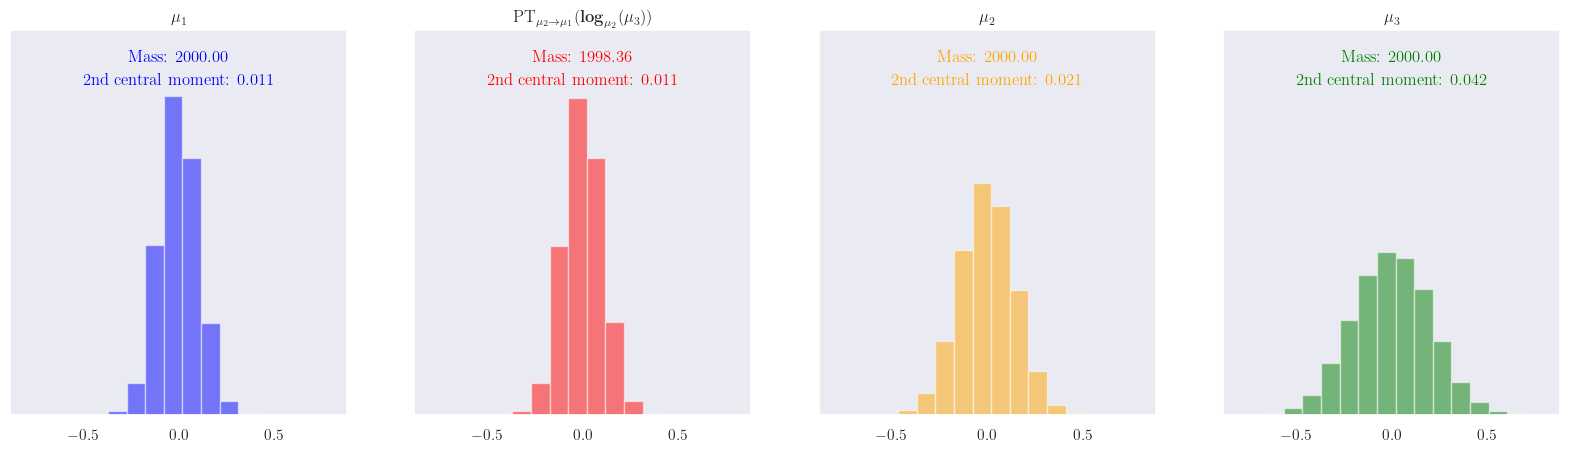

HK distance between mu2 and mu3: 8.379853918698371
HK distance between mu1 and mu3_at_mu1: 5.815659579439281


In [ ]:
# 1D covariance-change experiment with consistent scaling and diagnostics
n_1 = 2000
n_2 = 2000
n_3 = 2000

ldas = [1, 5, 10, 100, 1000]

mean_1 = np.array([0.0])
cov_1 = np.array([[2.0]])
mean_2 = np.array([0.0])
cov_2 = np.array([[4.0]])
mean_3 = np.array([0.0])
cov_3 = np.array([[8.0]])

rng = np.random.default_rng(1)
data_1 = rng.multivariate_normal(mean_1, cov_1, n_1)
data_2 = rng.multivariate_normal(mean_2, cov_2, n_2)
data_3 = rng.multivariate_normal(mean_3, cov_3, n_3)

# Scale everything to stay inside the cone geometry regime.
max_val = max(np.max(data_1), np.max(data_2), np.max(data_3))
min_val = min(np.min(data_1), np.min(data_2), np.min(data_3))
scale_factor = ((np.pi / 2) - 1e-1) / (max_val - min_val)

data_1_scaled = data_1 * scale_factor
data_2_scaled = data_2 * scale_factor
data_3_scaled = data_3 * scale_factor

print(f"Scaled mean_1: {mean_1 * scale_factor}, Scaled sigma_1: {np.sqrt(cov_1[0, 0]) * scale_factor}")
print(f"Scaled mean_2: {mean_2 * scale_factor}, Scaled sigma_2: {np.sqrt(cov_2[0, 0]) * scale_factor}")
print(f"Scaled mean_3: {mean_3 * scale_factor}, Scaled sigma_3: {np.sqrt(cov_3[0, 0]) * scale_factor}")

mu1 = hkpt.EmpiricalMeasure(data_1_scaled, weights=np.ones(n_1))
mu2 = hkpt.EmpiricalMeasure(data_2_scaled, weights=np.ones(n_2))
mu3 = hkpt.EmpiricalMeasure(data_3_scaled, weights=np.ones(n_3))

for lda in ldas:
    tangent_23 = hkpt.hk_logarithmic_map(
        mu2,
        mu3,
        allow_approximation=True,
        approximation_mode='barycentric',
        let_solver='pot_mm',
        scale=lda,
    )

    # Log/exp consistency check in the same scaled coordinates.
    mu3_at_mu2 = hkpt.hk_exponential_map(mu2, tangent_23, scale=lda)
    plt.figure(figsize=(10, 6))
    plt.hist(mu3.samples.flatten(), bins=30, weights=mu3.weights, label=r'$\mu_3$', color='green', alpha=0.5)
    plt.hist(mu3_at_mu2.samples.flatten(), bins=30, weights=mu3_at_mu2.weights, label=r'$\hat{\mu}_3 = \exp_{\mu_2}(\log_{\mu_2}(\mu_3))$', color='red', alpha=0.5)
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.show()

    print(f"mu3 mean: {np.mean(mu3.samples.flatten())}, mu3 var: {np.std(mu3.samples.flatten())}")
    print(f"mu3_at_mu2 mean: {np.mean(mu3_at_mu2.samples.flatten())}, mu3_at_mu2 var: {np.std(mu3_at_mu2.samples.flatten())}")

    tangent_23_at_mu1, pt_alignment_diag = hkpt.hk_parallel_transport(
        mu2,
        mu1,
        tangent_23,
        N=4,
        return_alignment_diagnostics=True,
        scale=lda,
    )

    if pt_alignment_diag['alignment_succeeded']:
        print("Parallel transport alignment succeeded")
    else:
        print(f"Parallel transport alignment failed with final alignment error {pt_alignment_diag['nearest_neighbor_distances'].max()}")

    mu3_at_mu1 = hkpt.hk_exponential_map(mu1, tangent_23_at_mu1, scale=lda)

    fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
    all_hist_samples = [
        mu1.samples.flatten(),
        mu2.samples.flatten(),
        mu3.samples.flatten(),
    ]
    if mu3_at_mu1 is not None:
        all_hist_samples.append(mu3_at_mu1.samples.flatten())
    combined_samples = np.concatenate(all_hist_samples)
    shared_bins = np.linspace(combined_samples.min(), combined_samples.max(), 16)

    subplot_measures = [
        (axs[0], mu1.samples.flatten(), mu1.weights, r'$\mu_1$', 'blue'),
        (axs[1], mu3_at_mu1.samples.flatten() if mu3_at_mu1 is not None else np.array([]), mu3_at_mu1.weights if mu3_at_mu1 is not None else np.array([]), r'$\mathrm{PT}_{\mu_2 \rightarrow \mu_1}(\mathbf{log}_{\mu_2}(\mu_3))$', 'red'),
        (axs[2], mu2.samples.flatten(), mu2.weights, r'$\mu_2$', 'orange'),
        (axs[3], mu3.samples.flatten(), mu3.weights, r'$\mu_3$', 'green'),
    ]

    for ax, samples, weights, title, color in subplot_measures:
        if samples.size:
            ax.hist(samples, bins=shared_bins, weights=weights, color=color, alpha=0.5)
        ax.set_title(title)
        ax.set_yticks([])
        ax.grid(False)

    plt.ylim(0, plt.ylim()[1] * 1.15)

    def weighted_second_moment(samples, weights):
        w = np.asarray(weights, dtype=float)
        w = w / np.sum(w)
        x = np.asarray(samples, dtype=float)
        m = np.sum(w * x)
        return np.sum(w * (x - m) ** 2)

    axs[0].text(0.5, 0.92, f"Mass: {mu1.weights.sum():.2f}", transform=axs[0].transAxes, color='blue', ha='center')
    axs[2].text(0.5, 0.92, f"Mass: {mu2.weights.sum():.2f}", transform=axs[2].transAxes, color='orange', ha='center')
    axs[3].text(0.5, 0.92, f"Mass: {mu3.weights.sum():.2f}", transform=axs[3].transAxes, color='green', ha='center')
    if mu3_at_mu1 is not None:
        axs[1].text(0.5, 0.92, f"Mass: {mu3_at_mu1.weights.sum():.2f}", transform=axs[1].transAxes, color='red', ha='center')

    axs[0].text(0.5, 0.86, f"2nd central moment: {weighted_second_moment(mu1.samples.flatten(), mu1.weights):.3f}", transform=axs[0].transAxes, color='blue', ha='center')
    axs[2].text(0.5, 0.86, f"2nd central moment: {weighted_second_moment(mu2.samples.flatten(), mu2.weights):.3f}", transform=axs[2].transAxes, color='orange', ha='center')
    axs[3].text(0.5, 0.86, f"2nd central moment: {weighted_second_moment(mu3.samples.flatten(), mu3.weights):.3f}", transform=axs[3].transAxes, color='green', ha='center')
    if mu3_at_mu1 is not None:
        axs[1].text(0.5, 0.86, f"2nd central moment: {weighted_second_moment(mu3_at_mu1.samples.flatten(), mu3_at_mu1.weights):.3f}", transform=axs[1].transAxes, color='red', ha='center')

    max_abs_x = np.max(np.abs(combined_samples))
    for ax in axs:
        ax.set_xlim(-1.1 * max_abs_x, 1.1 * max_abs_x)

    plt.savefig(f'../Figures/HK_parallel_transport_1d_cov_change_scale_{lda}.pdf', dpi=800)
    plt.show()

    hk_distance_mu2_mu3 = hkpt.hk_distance(mu2, mu3, scale=lda)
    hk_distance_mu1_mu3_at_mu1 = hkpt.hk_distance(mu1, mu3_at_mu1, scale=lda)
    print(f"HK distance between mu2 and mu3: {hk_distance_mu2_mu3}")
    print(f"HK distance between mu1 and mu3_at_mu1: {hk_distance_mu1_mu3_at_mu1}")